In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("viridis")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving NYC_Data.csv to NYC_Data.csv
Saving LA_Data.csv to LA_Data.csv


In [ ]:
la_df = pd.read_csv("LA_Data.csv")
nyc_df = pd.read_csv("NYC_Data.csv")

In [ ]:
def prepare_data(df, city_name):
    df_clean = df.copy()

    df_clean.rename(columns={
        'Daily AQI Value': 'AQI',
        'Pollutant': 'pollutant'
    }, inplace=True)

    # Convert to datetime
    df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
    df_clean = df_clean.dropna(subset=['Date'])

    # Extract time features
    df_clean['year'] = df_clean['Date'].dt.year
    df_clean['month'] = df_clean['Date'].dt.month
    df_clean['day_of_week'] = df_clean['Date'].dt.dayofweek
    df_clean['day_of_year'] = df_clean['Date'].dt.dayofyear

    # Add city identifier
    df_clean['city'] = city_name

    return df_clean

# Prepare both datasets
la_clean = prepare_data(la_df, 'LA')
nyc_clean = prepare_data(nyc_df, 'NYC')

# Combine data
combined_df = pd.concat([la_clean, nyc_clean], ignore_index=True)

In [ ]:
def create_features(df, target='AQI', lags=7):

    df_feat = df.copy()

    # Create lag features
    for lag in range(1, lags + 1):
        df_feat[f'lag_{lag}'] = df_feat[target].shift(lag)

    # Rolling statistics
    df_feat['rolling_mean_7'] = df_feat[target].rolling(window=7).mean()
    df_feat['rolling_std_7'] = df_feat[target].rolling(window=7).std()

    return df_feat

#Feature engineering for each pollutant and city
pollutants = combined_df['pollutant'].unique()
cities = combined_df['city'].unique()

all_features = []
for city in cities:
    for poll in pollutants:
        city_poll_df = combined_df[(combined_df['city'] == city) &
                                  (combined_df['pollutant'] == poll)].copy()
        if not city_poll_df.empty:
            city_poll_feat = create_features(city_poll_df)
            all_features.append(city_poll_feat)

#Combine all features
features_df = pd.concat(all_features, ignore_index=True)
features_df = features_df.dropna()

print(f"Final dataset shape: {features_df.shape}")
print(f"Columns: {features_df.columns.tolist()}")

Final dataset shape: (7444, 34)
Columns: ['Date', 'Source', 'POC', 'Daily Max 8-hour CO Concentration', 'Units', 'AQI', 'Local Site Name', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'pollutant', 'Method Code', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State', 'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude', 'year', 'month', 'day_of_week', 'day_of_year', 'city', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'rolling_mean_7', 'rolling_std_7']


In [ ]:
def prepare_ml_data(df, val_size=0.1, test_size=0.1):
    df = df.sort_values('Date').reset_index(drop=True)

    #Split features and target
    X = df.drop(['AQI', 'Date', 'city', 'pollutant', 'Source', 'Units', 'Local Site Name', 'CBSA Name', 'State', 'County'], axis=1, errors='ignore')
    y = df['AQI']

    total_size = len(X)
    test_split = int(total_size * (1 - test_size))
    val_split = int(test_split * (1 - val_size / (1 - test_size)))

    #Create splits
    X_train, X_temp = X.iloc[:val_split], X.iloc[val_split:test_split]
    X_val, X_test = X_temp.iloc[:len(X_temp)//2], X_temp.iloc[len(X_temp)//2:]

    y_train, y_temp = y.iloc[:val_split], y.iloc[val_split:test_split]
    y_val, y_test = y_temp.iloc[:len(y_temp)//2], y_temp.iloc[len(y_temp)//2:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    print(f"Data split: Train={len(X_train)} ({len(X_train)/total_size*100:.1f}%), "
          f"Val={len(X_val)} ({len(X_val)/total_size*100:.1f}%), "
          f"Test={len(X_test)} ({len(X_test)/total_size*100:.1f}%)")

    return (X_train_scaled, X_val_scaled, X_test_scaled,
            y_train, y_val, y_test, scaler, X.columns)

#Prepare data for each pollutant and city with 80/10/10 split
ml_data = {}
for city in cities:
    for poll in pollutants:
        city_poll_data = features_df[(features_df['city'] == city) &
                                    (features_df['pollutant'] == poll)]
        if len(city_poll_data) > 100:
            print(f"\nPreparing data for {city}_{poll}:")
            X_train, X_val, X_test, y_train, y_val, y_test, scaler, feature_names = prepare_ml_data(city_poll_data)
            ml_data[f'{city}_{poll}'] = {
                'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
                'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
                'scaler': scaler, 'feature_names': feature_names
            }


Preparing data for LA_Carbon monoxide:
Data split: Train=2923 (80.0%), Val=183 (5.0%), Test=183 (5.0%)

Preparing data for NYC_Carbon monoxide:
Data split: Train=3031 (80.0%), Val=189 (5.0%), Test=190 (5.0%)


In [ ]:
def train_models_with_val(X_train, y_train, X_val, y_val):
    models = {}

    # 1. Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    models['RandomForest'] = rf

    # 2. XGBoost with early stopping
    xg_reg = xgb.XGBRegressor(n_estimators=1000, random_state=42, early_stopping_rounds=50)
    xg_reg.fit(X_train, y_train,
               eval_set=[(X_val, y_val)],
               verbose=False)
    models['XGBoost'] = xg_reg

    return models

def evaluate_models(models, X_test, y_test):

    results = {}
    for name, model in models.items():
        y_pred = model.predict(X_test)
        results[name] = {
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'R2': r2_score(y_test, y_pred)
        }
    return pd.DataFrame(results).T

# Train and evaluate for each dataset
results = {}
for key, data in ml_data.items():
    print(f"\nTraining models for: {key}")
    models = train_models_with_val(data['X_train'], data['y_train'],
                                  data['X_val'], data['y_val'])
    results[key] = evaluate_models(models, data['X_test'], data['y_test'])

    # Display results
    print(f"Test results for {key}:")
    print(results[key])
    print("-" * 50)


Training models for: LA_Carbon monoxide
Test results for LA_Carbon monoxide:
                   MAE      RMSE        R2
RandomForest  0.006503  0.075245  0.999260
XGBoost       0.005543  0.073928  0.999286
--------------------------------------------------

Training models for: NYC_Carbon monoxide
Test results for NYC_Carbon monoxide:
                   MAE      RMSE        R2
RandomForest  0.000211  0.002902  0.999998
XGBoost       0.000010  0.000018  1.000000
--------------------------------------------------


In [ ]:
import tensorflow as tf

def create_lstm_model(input_shape):

    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Train LSTM for each dataset with validation
lstm_results = {}
lstm_trained_models = {} # Dictionary to store trained LSTM models
for key, data in ml_data.items():
    print(f"\nTraining LSTM for: {key}")

    # Prepare LSTM data
    def prepare_lstm_data_3d(X, y, time_steps=7):
        X_lstm, y_lstm = [], []
        for i in range(time_steps, len(X)):
            X_lstm.append(X[i-time_steps:i])
            y_lstm.append(y.iloc[i] if hasattr(y, 'iloc') else y[i])
        return np.array(X_lstm), np.array(y_lstm)

    # Convert to DataFrame for the shift operation
    X_train_df = pd.DataFrame(data['X_train'])
    X_val_df = pd.DataFrame(data['X_val'])
    X_test_df = pd.DataFrame(data['X_test'])


    X_train_lstm, y_train_lstm = prepare_lstm_data_3d(X_train_df, data['y_train'])
    X_val_lstm, y_val_lstm = prepare_lstm_data_3d(X_val_df, data['y_val'])
    X_test_lstm, y_test_lstm = prepare_lstm_data_3d(X_test_df, data['y_test'])


    # Create and train model with validation
    model = create_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))
    history = model.fit(X_train_lstm, y_train_lstm,
                       epochs=100,
                       batch_size=32,
                       validation_data=(X_val_lstm, y_val_lstm),
                       verbose=0,
                       callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])

    # Store the trained model
    lstm_trained_models[key] = model

    # Evaluate on test set
    y_pred = model.predict(X_test_lstm)
    lstm_results[key] = {
        'MAE': mean_absolute_error(y_test_lstm, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_lstm, y_pred)),
        'R2': r2_score(y_test_lstm, y_pred)
    }

    print(f"LSTM Test results for {key}:")
    print(lstm_results[key])
    print("-" * 50)


Training LSTM for: LA_Carbon monoxide


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
LSTM Test results for LA_Carbon monoxide:
{'MAE': 1.7149200439453125, 'RMSE': np.float64(2.0617400416539255), 'R2': 0.44824039936065674}
--------------------------------------------------

Training LSTM for: NYC_Carbon monoxide


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step
LSTM Test results for NYC_Carbon monoxide:
{'MAE': 1.3999584913253784, 'RMSE': np.float64(1.804061252547969), 'R2': 0.23935359716415405}
--------------------------------------------------


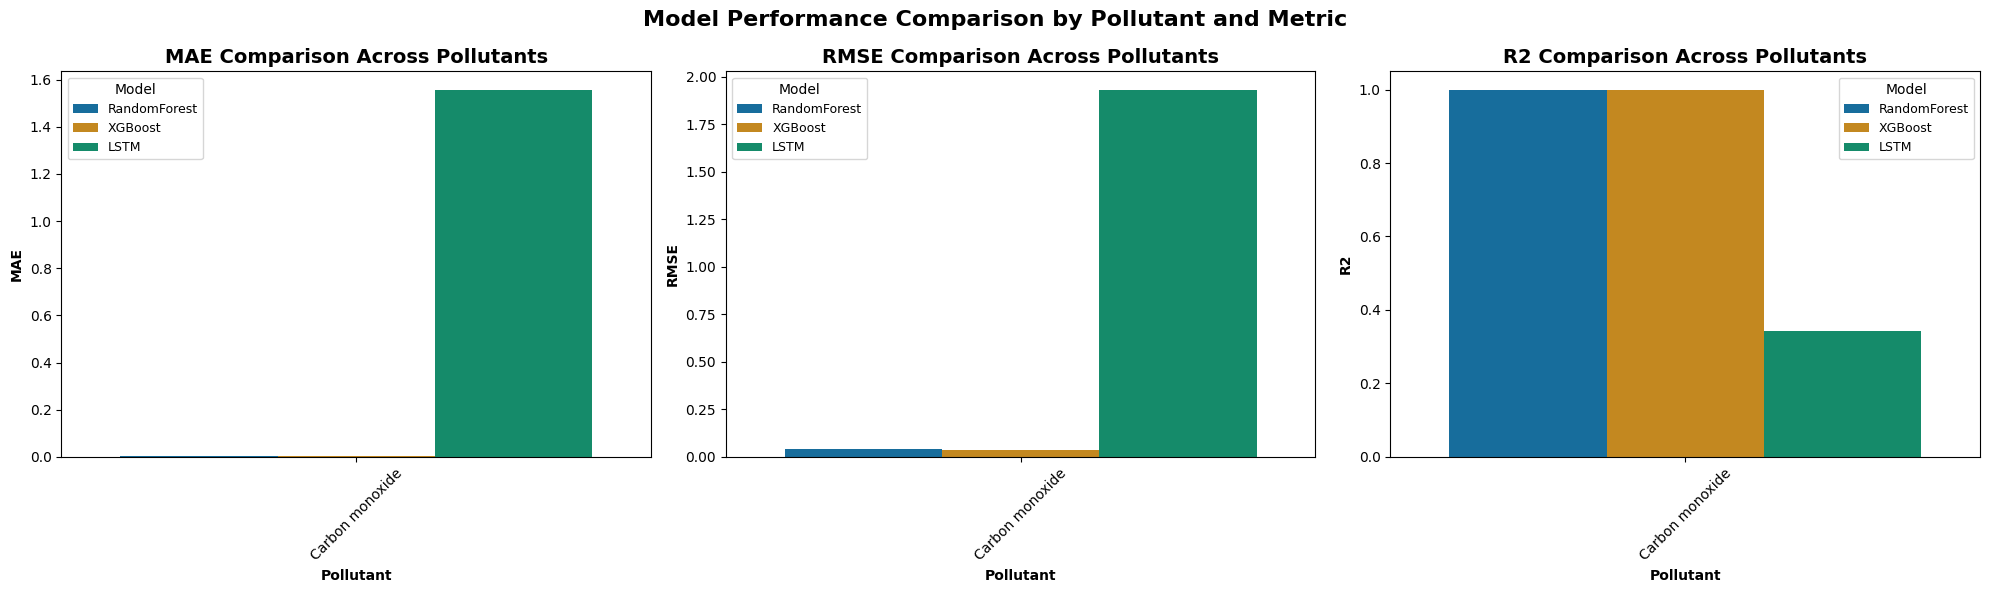


Creating Actual vs Predicted plots for: LA_Carbon monoxide
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


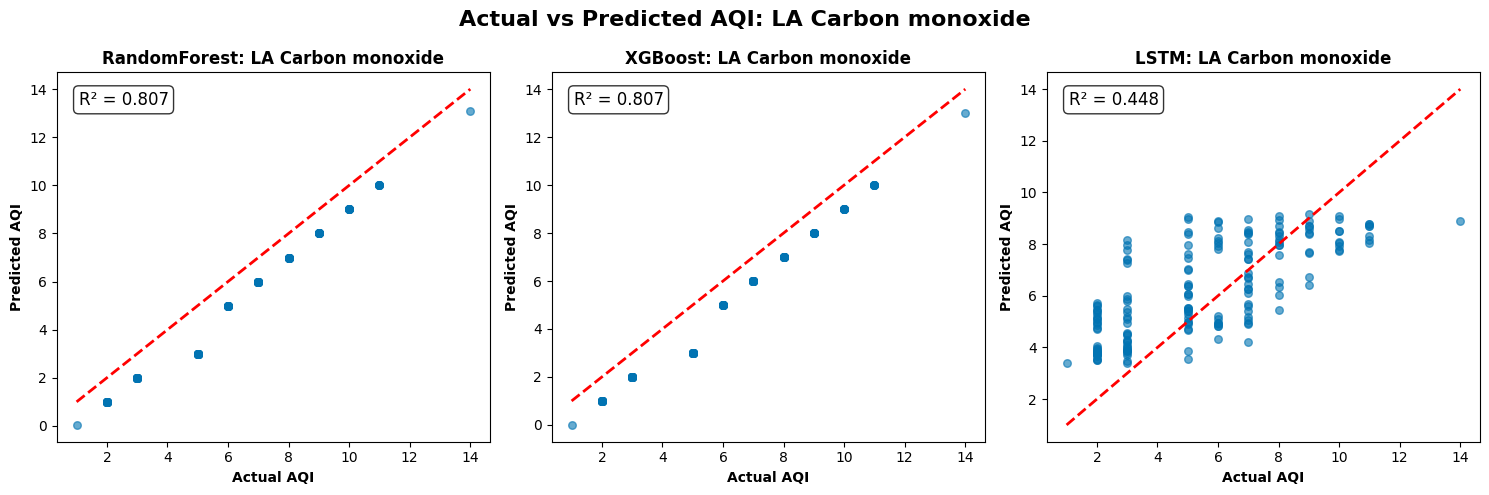


Creating Actual vs Predicted plots for: NYC_Carbon monoxide
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


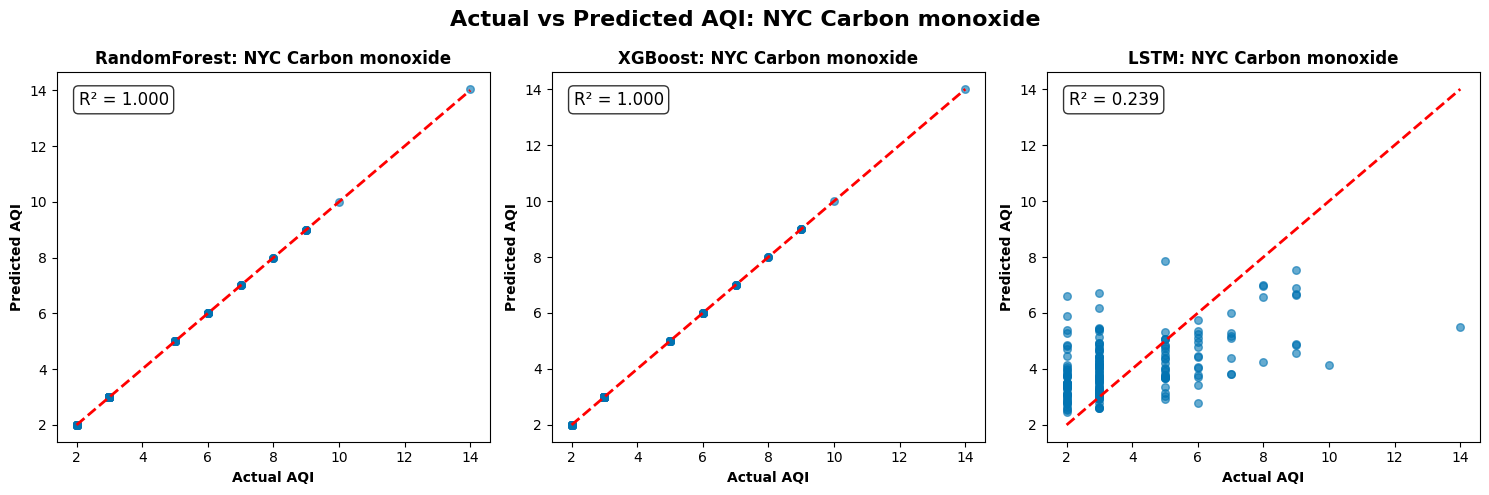


Creating Time Series Forecast plots for: LA_Carbon monoxide
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


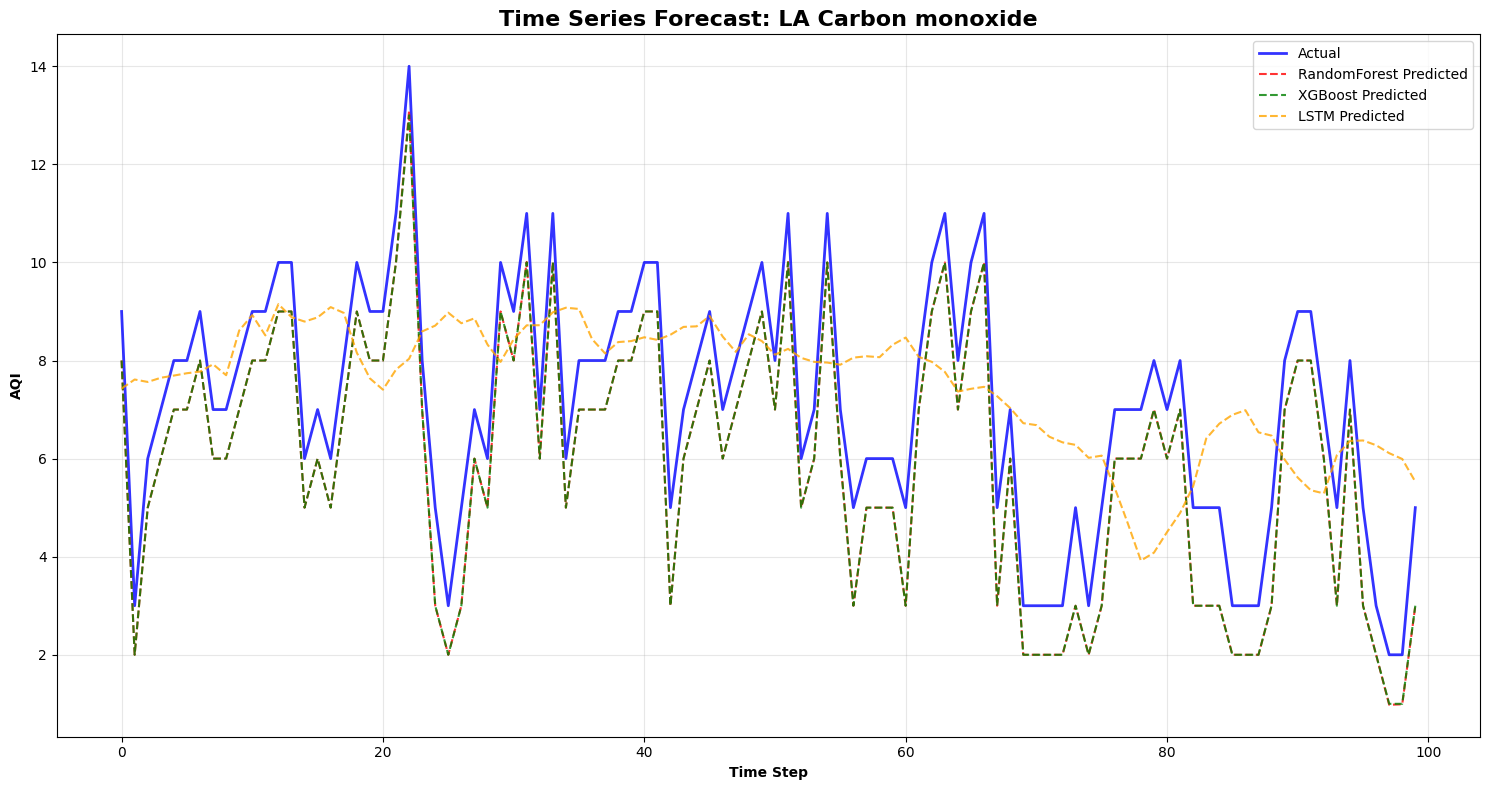


Creating Time Series Forecast plots for: NYC_Carbon monoxide
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


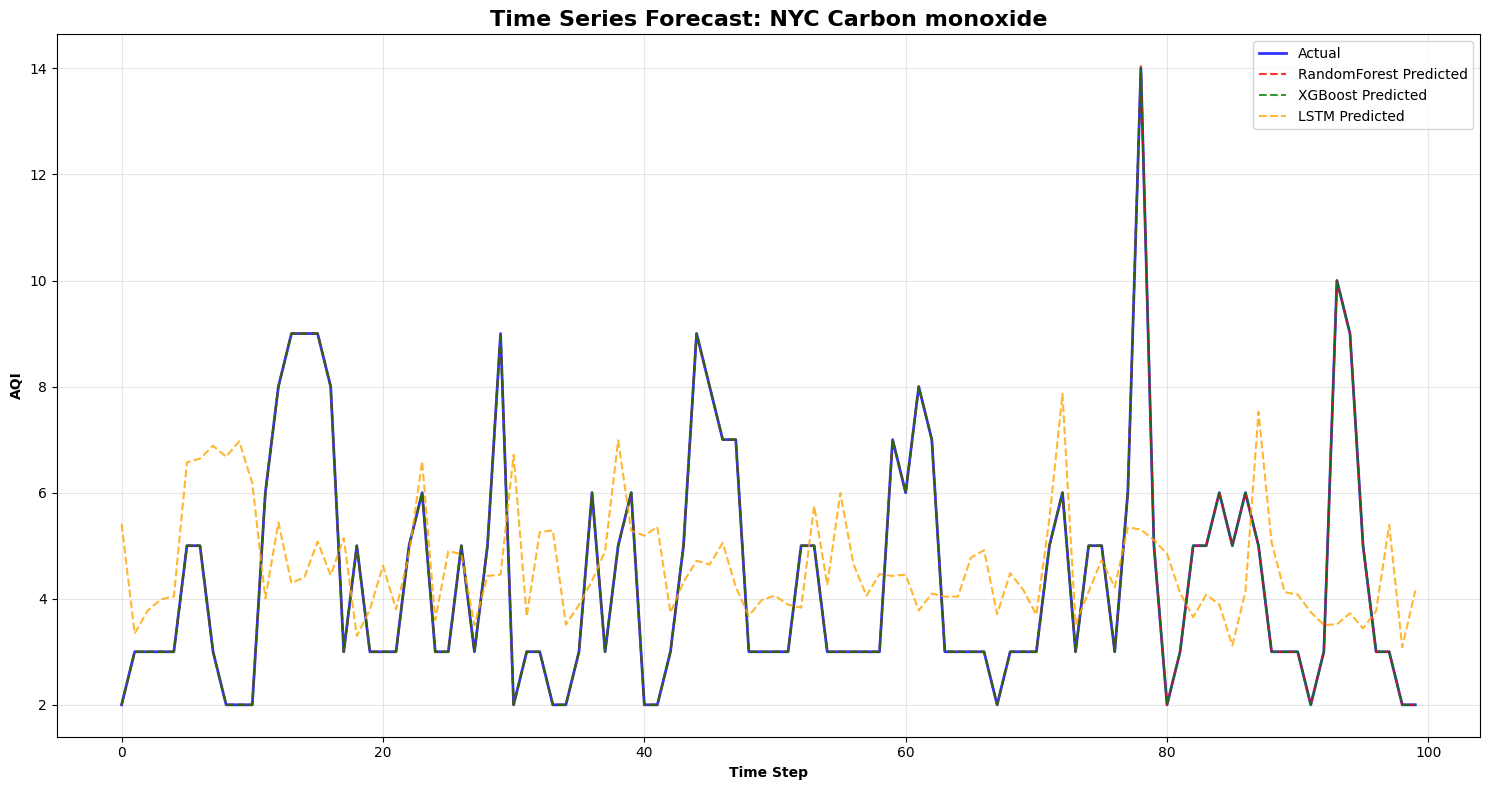


Creating Feature Importance plots for: LA_Carbon monoxide


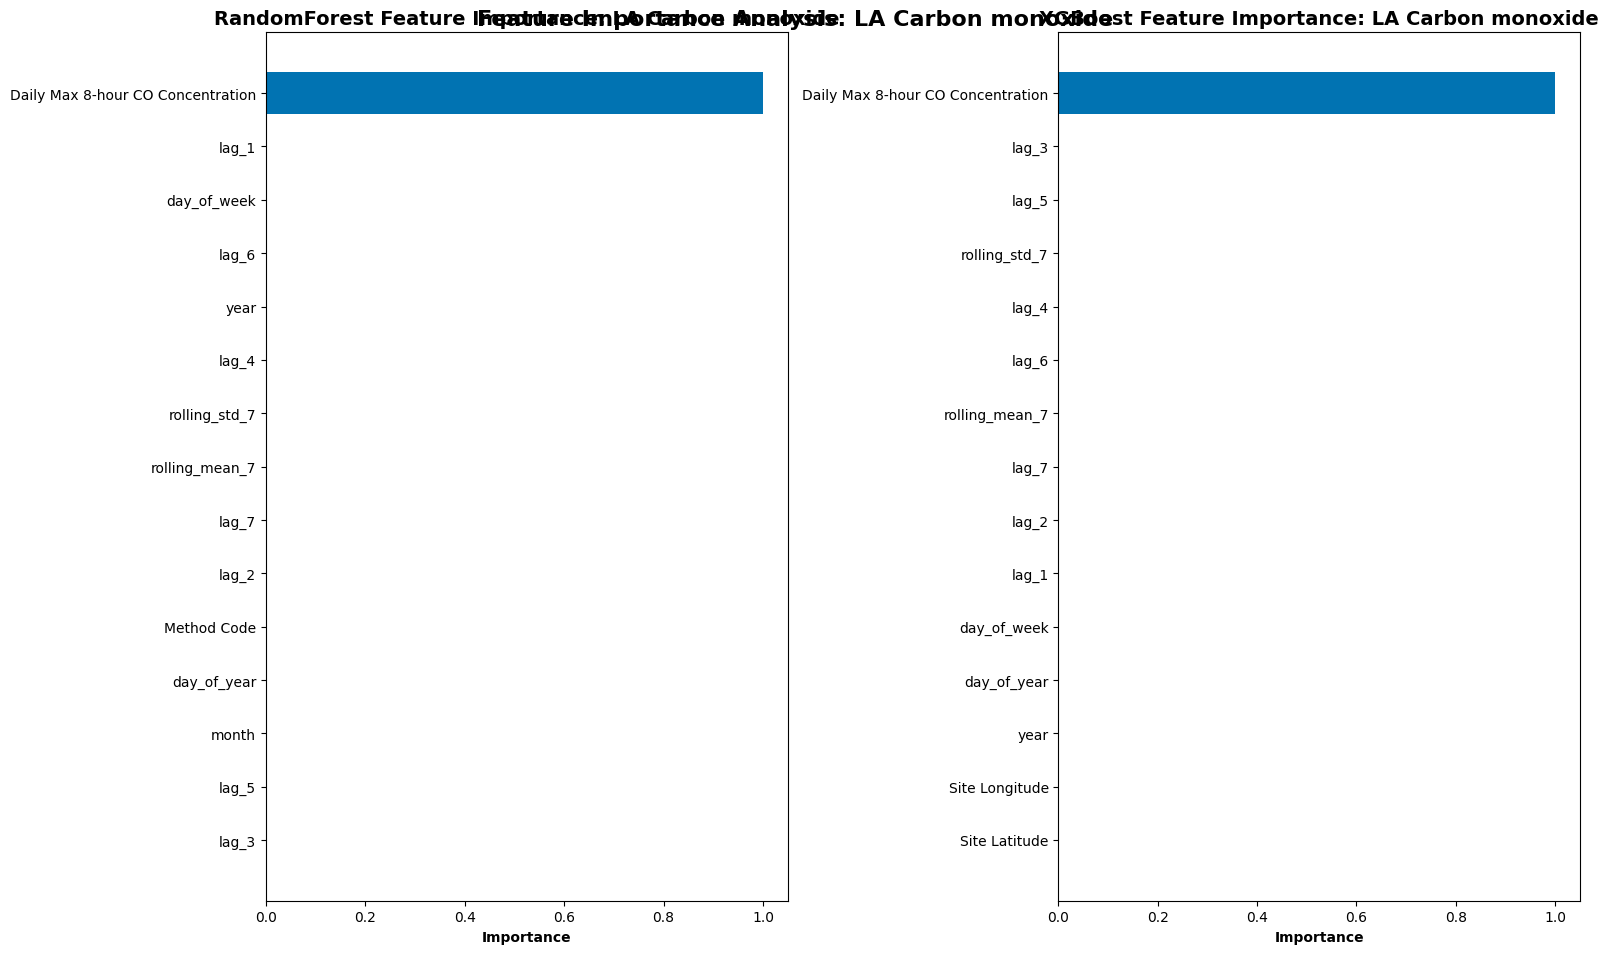


Creating Feature Importance plots for: NYC_Carbon monoxide


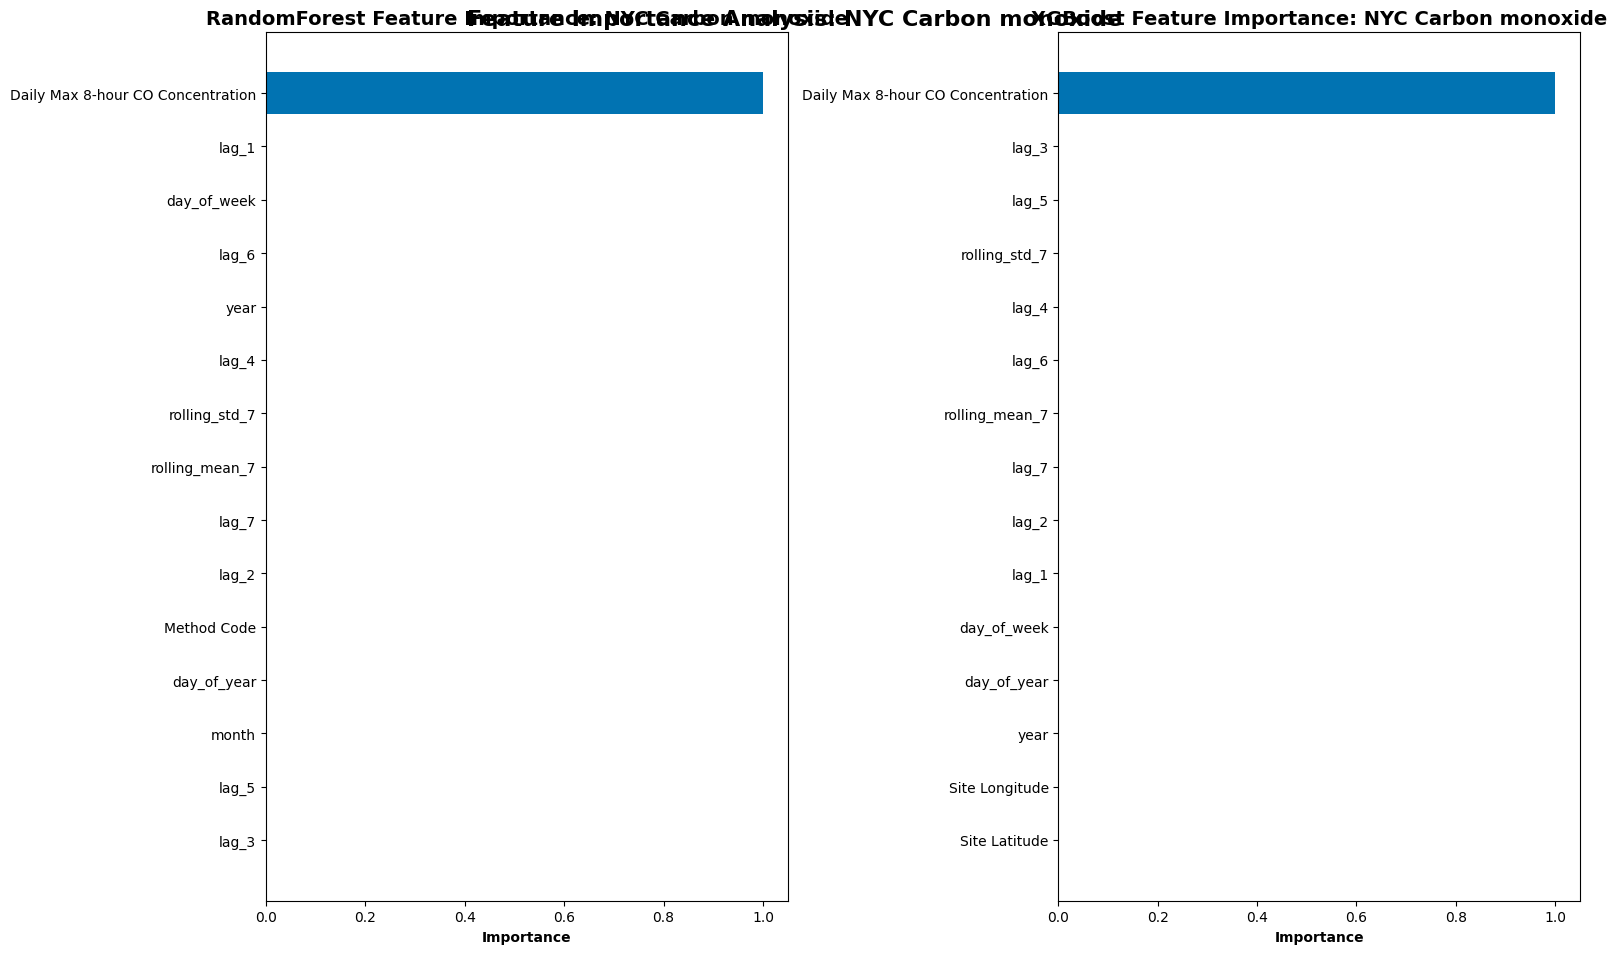


Creating Error Distribution plots for: LA_Carbon monoxide
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


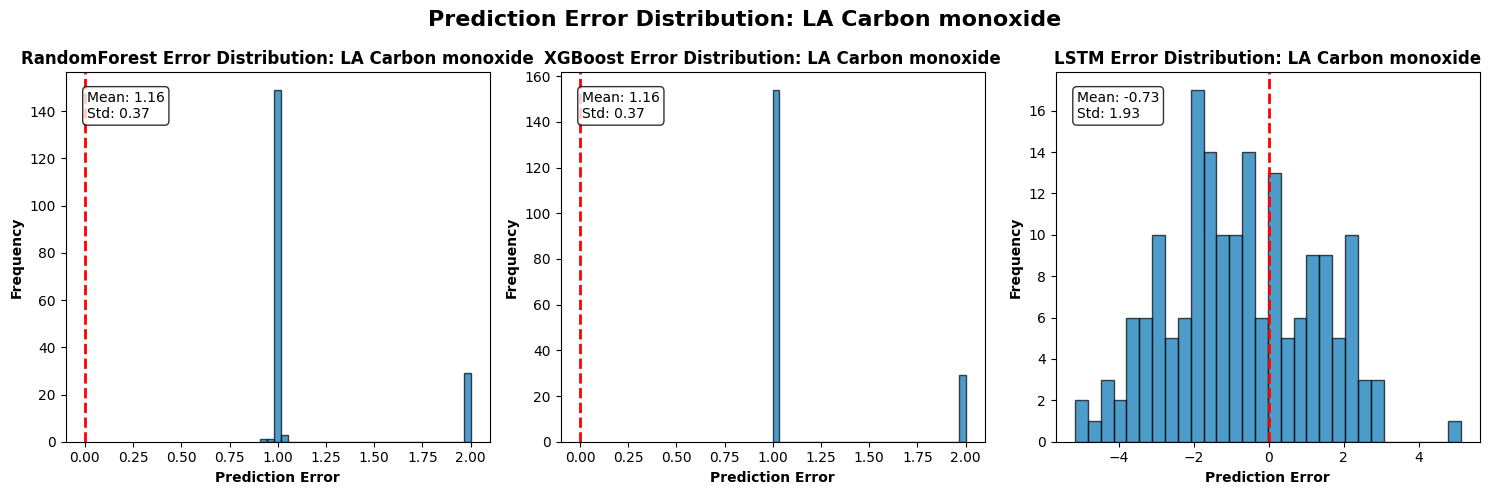


Creating Error Distribution plots for: NYC_Carbon monoxide
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


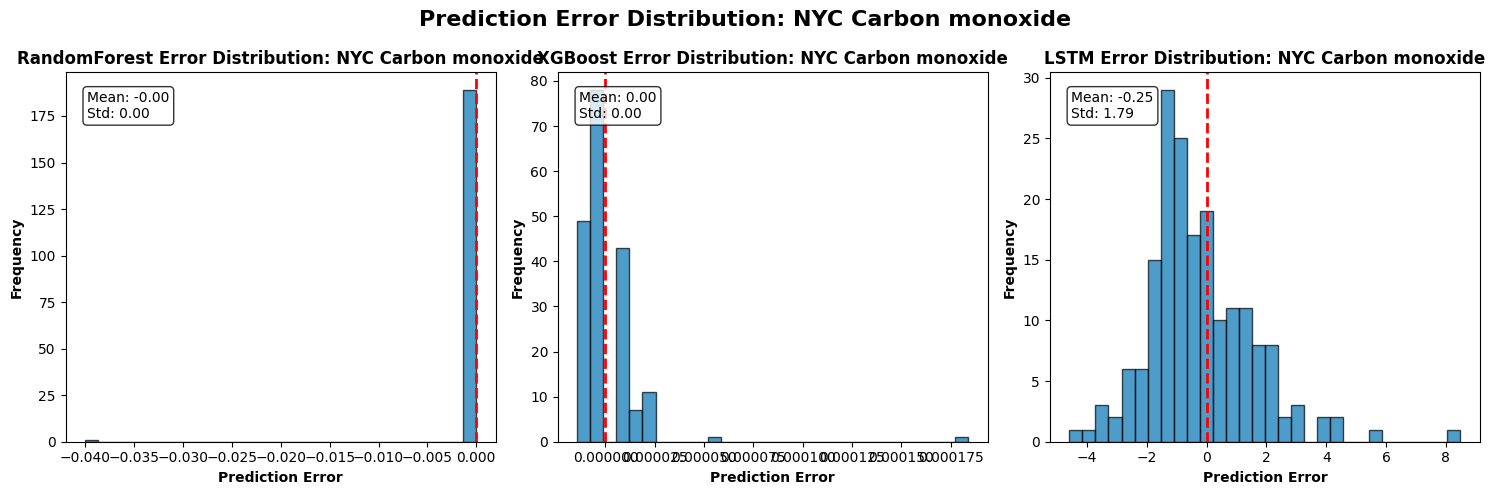

Generating all visualizations...
All visualizations completed!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
sns.set_palette("colorblind")

# 1. Model Performance Comparison Bar Chart
def plot_model_comparison(results_dict):

    metrics = ['MAE', 'RMSE', 'R2']
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    for i, metric in enumerate(metrics):
        metric_data = []
        for dataset, df in results_dict.items():
            city, poll = dataset.split('_')
            for model in df.index:
                metric_data.append({
                    'Model': model,
                    'Value': df.loc[model, metric],
                    'Dataset': dataset,
                    'City': city,
                    'Pollutant': poll
                })

        metric_df = pd.DataFrame(metric_data)

        # Create grouped bar plot
        sns.barplot(data=metric_df, x='Pollutant', y='Value', hue='Model',
                   ax=axes[i], errorbar=None)

        axes[i].set_title(f'{metric} Comparison Across Pollutants', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Pollutant', fontweight='bold')
        axes[i].set_ylabel(metric, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(title='Model', title_fontsize=10, fontsize=9)

    plt.suptitle('Model Performance Comparison by Pollutant and Metric',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Combine results for all models
all_results = {}
for key in results.keys():
    all_results[key] = pd.concat([results[key], pd.DataFrame(lstm_results[key], index=['LSTM'])])

# Generate the comparison plot
plot_model_comparison(all_results)

# 2. Actual vs Predicted Scatter Plots
def plot_actual_vs_predicted(models, data, dataset_key):

    city, poll = dataset_key.split('_')
    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))

    if n_models == 1:
        axes = [axes]

    for idx, (model_name, model) in enumerate(models.items()):
        if model_name == 'LSTM':
            # For LSTM, we need to use the prepared LSTM test data
            X_test_df = pd.DataFrame(data['X_test'])
            X_test_lstm, y_test_lstm = prepare_lstm_data_3d(X_test_df, data['y_test'])
            y_pred = model.predict(X_test_lstm).flatten()
            y_actual = y_test_lstm
        else:
            y_pred = model.predict(data['X_test'])
            y_actual = data['y_test'].values

        # Create scatter plot
        axes[idx].scatter(y_actual, y_pred, alpha=0.6, s=30)
        axes[idx].plot([y_actual.min(), y_actual.max()],
                      [y_actual.min(), y_actual.max()], 'r--', lw=2)

        axes[idx].set_xlabel('Actual AQI', fontweight='bold')
        axes[idx].set_ylabel('Predicted AQI', fontweight='bold')
        axes[idx].set_title(f'{model_name}: {city} {poll}', fontweight='bold')

        # Add R² to plot
        r2 = r2_score(y_actual, y_pred)
        axes[idx].text(0.05, 0.95, f'R² = {r2:.3f}', transform=axes[idx].transAxes,
                      fontsize=12, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.suptitle(f'Actual vs Predicted AQI: {city} {poll}',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(f'actual_vs_predicted_{dataset_key}.png', dpi=300, bbox_inches='tight')
    plt.show()

for key in ml_data.keys():
    print(f"\nCreating Actual vs Predicted plots for: {key}")
    # Need to pass the models and data for the specific key
    current_models = {name: model for name, model in models.items()}
    # Add LSTM model to current_models
    # Access the trained LSTM model directly from the variable
    lstm_model = lstm_trained_models[key] # Access the trained LSTM model from the dictionary
    current_models['LSTM'] = lstm_model
    plot_actual_vs_predicted(current_models, ml_data[key], key)


# 3. Time Series Forecast Visualization
def plot_forecast_timeseries(models, data, dataset_key, n_points=100):
    """
    Plot time series of actual vs predicted values
    """
    city, poll = dataset_key.split('_')

    # Get the test data
    X_test = data['X_test']
    y_test = data['y_test'].values

    # Select a subset for clearer visualization
    if len(y_test) > n_points:
        y_test_subset = y_test[:n_points]
    else:
        y_test_subset = y_test
        n_points = len(y_test)

    plt.figure(figsize=(15, 8))

    # Plot actual values
    plt.plot(range(n_points), y_test_subset, 'b-', label='Actual', linewidth=2, alpha=0.8)

    # Plot predictions for each model
    colors = ['red', 'green', 'orange', 'purple']
    for idx, (model_name, model) in enumerate(models.items()):
        if model_name == 'LSTM':
            # Handle LSTM predictions
            X_test_df = pd.DataFrame(data['X_test'])
            X_test_lstm, _ = prepare_lstm_data_3d(X_test_df, data['y_test'])
            y_pred = model.predict(X_test_lstm).flatten()[:n_points]
        else:
            y_pred = model.predict(X_test)[:n_points]

        plt.plot(range(n_points), y_pred, '--',
                color=colors[idx % len(colors)],
                label=f'{model_name} Predicted',
                linewidth=1.5, alpha=0.8)

    plt.xlabel('Time Step', fontweight='bold')
    plt.ylabel('AQI', fontweight='bold')
    plt.title(f'Time Series Forecast: {city} {poll}', fontsize=16, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'timeseries_forecast_{dataset_key}.png', dpi=300, bbox_inches='tight')
    plt.show()

for key in ml_data.keys():
    print(f"\nCreating Time Series Forecast plots for: {key}")
    current_models = {name: model for name, model in models.items()}
    # Add LSTM model to current_models
    # Access the trained LSTM model directly from the variable
    lstm_model = lstm_trained_models[key] # Access the trained LSTM model from the dictionary
    current_models['LSTM'] = lstm_model
    plot_forecast_timeseries(current_models, ml_data[key], key)


# 4. Feature Importance Plot (for tree-based models)
def plot_feature_importance(models, feature_names, dataset_key):
    """
    Plot feature importance for tree-based models
    """
    city, poll = dataset_key.split('_')
    tree_models = {k: v for k, v in models.items() if k in ['RandomForest', 'XGBoost']}

    n_models = len(tree_models)
    if n_models > 0:
        fig, axes = plt.subplots(1, n_models, figsize=(8*n_models, 10))

        if n_models == 1:
            axes = [axes]

        for idx, (model_name, model) in enumerate(tree_models.items()):
            if model_name == 'RandomForest':
                importance = model.feature_importances_
            else:  # XGBoost
                importance = model.feature_importances_

            # Create DataFrame for plotting
            feat_imp_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importance
            }).sort_values('importance', ascending=True).tail(15)

            # Plot horizontal bar chart
            axes[idx].barh(range(len(feat_imp_df)), feat_imp_df['importance'])
            axes[idx].set_yticks(range(len(feat_imp_df)))
            axes[idx].set_yticklabels(feat_imp_df['feature'])
            axes[idx].set_xlabel('Importance', fontweight='bold')
            axes[idx].set_title(f'{model_name} Feature Importance: {city} {poll}',
                              fontsize=14, fontweight='bold')

        plt.suptitle(f'Feature Importance Analysis: {city} {poll}',
                    fontsize=16, fontweight='bold', y=0.95)
        plt.tight_layout()
        plt.savefig(f'feature_importance_{dataset_key}.png', dpi=300, bbox_inches='tight')
        plt.show()

for key in ml_data.keys():
    print(f"\nCreating Feature Importance plots for: {key}")
    # Need to pass the models and feature names for the specific key
    current_models = {name: model for name, model in models.items()} # Assuming 'models' still holds RF and XGBoost
    plot_feature_importance(current_models, ml_data[key]['feature_names'], key)


# 5. Error Distribution Plot
def plot_error_distribution(models, data, dataset_key):
    """
    Plot distribution of prediction errors
    """
    city, poll = dataset_key.split('_')
    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))

    if n_models == 1:
        axes = [axes]

    for idx, (model_name, model) in enumerate(models.items()):
        if model_name == 'LSTM':
            X_test_df = pd.DataFrame(data['X_test'])
            X_test_lstm, y_test_lstm = prepare_lstm_data_3d(X_test_df, data['y_test'])
            y_pred = model.predict(X_test_lstm).flatten()
            errors = y_test_lstm - y_pred
        else:
            y_pred = model.predict(data['X_test'])
            errors = data['y_test'].values - y_pred

        axes[idx].hist(errors, bins=30, alpha=0.7, edgecolor='black')
        axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[idx].set_xlabel('Prediction Error', fontweight='bold')
        axes[idx].set_ylabel('Frequency', fontweight='bold')
        axes[idx].set_title(f'{model_name} Error Distribution: {city} {poll}',
                          fontweight='bold')

        # Add statistics
        mean_error = np.mean(errors)
        std_error = np.std(errors)
        axes[idx].text(0.05, 0.95, f'Mean: {mean_error:.2f}\nStd: {std_error:.2f}',
                      transform=axes[idx].transAxes, fontsize=10,
                      verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.suptitle(f'Prediction Error Distribution: {city} {poll}',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(f'error_distribution_{dataset_key}.png', dpi=300, bbox_inches='tight')
    plt.show()

for key in ml_data.keys():
    print(f"\nCreating Error Distribution plots for: {key}")
    current_models = {name: model for name, model in models.items()}
    # Add LSTM model to current_models
    # Access the trained LSTM model directly from the variable
    lstm_model = lstm_trained_models[key] # Access the trained LSTM model from the dictionary
    current_models['LSTM'] = lstm_model
    plot_error_distribution(current_models, ml_data[key], key)


print("Generating all visualizations...")


print("All visualizations completed!")